We'll show a basic 3d graph of the current active cases of the
local government areas. We'll order by the total number of cases so as
to make the highest peaks at back, keeping the front peaks unobscured.

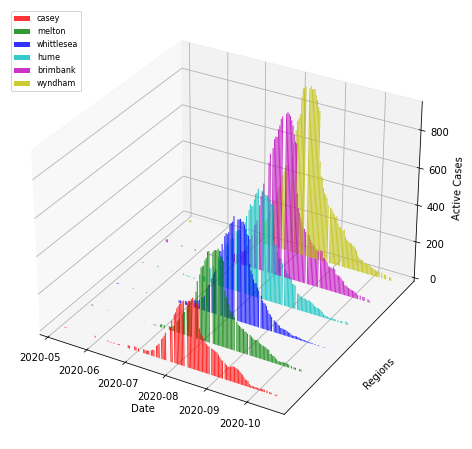

In [14]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-bright')

# Show the Google mobility data
data = requests.get('http://langlynx.ddns.net:8000/case_data_time_series',
                    params={'schema': 'lga',
                            'region_parent': 'au-vic'}
                    ).json()
vic_dhhs = data['vic_press_releases']

colors = ['r', 'g', 'b', 'c', 'm', 'y']
region_children = [(vic_dhhs['total'][k][-1][1], k) for k in vic_dhhs['total']]
region_children = [i[1] for i in sorted(region_children, reverse=True)][:len(colors)]
region_children = region_children[::-1]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

for c, region_child in zip(colors, region_children):
    totals = [i[1] for i in vic_dhhs['status_active'][region_child] if i[1] > -100]
    dates = [i[0] for i in vic_dhhs['status_active'][region_child] if i[1] > -100]

    df = pd.DataFrame({'dates': pd.to_datetime(dates, format="%d-%m-%Y"),
                       'totals': totals})

    ax.bar(list(df.dates.values),
           list(df.totals.values),
           zs=region_children.index(region_child),
           zdir='y',
           color=c,
           alpha=0.8,
           label=region_child)

leg = ax.legend(loc='upper left', fontsize=8)

ax.set_xlabel('Date')
ax.set_ylabel('Regions')
ax.set_yticks([])
ax.set_zlabel('Active Cases')

plt.show()